
# QSVM for Malware Family Classification using Dynamic CAPA Features

This Colab notebook trains a **Quantum Support Vector Machine (QSVM)** for **malware family classification** using the uploaded dataset: `Dynamic Data for Malware Family Classification.zip`.

Because current QML/QSVM experiments are expensive for large datasets, this notebook uses an educational/research-friendly pipeline:

1. Load the dynamic malware CAPA feature dataset.
2. Select the top malware families.
3. Reduce the feature dimension to a small number of qubits using feature selection/PCA.
4. Encode features into a quantum feature map.
5. Compute a quantum kernel.
6. Train QSVC/QSVM.
7. Compare with a classical SVM baseline.

**Important:** We should run the QSVM on a simulator first. Real IBM quantum hardware should be used only for small demonstrations because kernel computation requires many circuit evaluations.



## 1. Install packages

Run this cell in Google Colab. If Colab asks to restart the runtime after installation, restart and continue from the next cell.


In [ ]:

!pip -q install qiskit qiskit-machine-learning scikit-learn pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.0 MB/s eta 0:00:00



## 2. Upload and extract dataset

Upload the file named:

`Dynamic Data for Malware Family Classification.zip`

You can either upload it manually using the Colab file browser or run the upload cell below.


In [ ]:

from google.colab import files
uploaded = files.upload()


Saving Dynamic Data for Malware Family Classification.zip to Dynamic Data for Malware Family Classification.zip


In [ ]:

import os, zipfile, glob

ZIP_NAME = 'Dynamic Data for Malware Family Classification.zip'

# If the uploaded filename has a slightly different name, pick the first zip file.
if not os.path.exists(ZIP_NAME):
    zip_files = glob.glob('*.zip')
    if not zip_files:
        raise FileNotFoundError('Please upload the dataset zip file.')
    ZIP_NAME = zip_files[0]

EXTRACT_DIR = '/content/malware_dynamic_dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_NAME, 'r') as z:
    z.extractall(EXTRACT_DIR)

csv_files = glob.glob(EXTRACT_DIR + '/**/*.csv', recursive=True)
print('Found CSV files:')
for f in csv_files:
    print(f)


Found CSV files:
/content/malware_dynamic_dataset/Dynamic Data for Malware Family Classification/Static_Capa_Feature_Space.csv
/content/malware_dynamic_dataset/Dynamic Data for Malware Family Classification/Dynamic_Capa_Feature_Space.csv
/content/malware_dynamic_dataset/Dynamic Data for Malware Family Classification/Dynamic_Capa_Feature_Space_2.csv



## 3. Load the dynamic feature dataset

This zip file contains multiple CSV files. For QSVM, we will use:

`Dynamic_Capa_Feature_Space.csv`

This file has a `family` column as the label and CAPA behavior features as input variables.


In [ ]:

import pandas as pd
import numpy as np

# Prefer the dynamic CAPA feature file
preferred = [f for f in csv_files if f.endswith('Dynamic_Capa_Feature_Space.csv')]
if preferred:
    data_path = preferred[0]
else:
    data_path = csv_files[0]

print('Using:', data_path)
df = pd.read_csv(data_path)
print('Shape:', df.shape)
df.head()


Using: /content/malware_dynamic_dataset/Dynamic Data for Malware Family Classification/Dynamic_Capa_Feature_Space.csv
Shape: (3589, 254)


,family,accept command line arguments,access firewall settings via INetFwMgr,access PE header,access the Windows event log,add file to cabinet file,add user account group,add user account to group,add user account,allocate memory,...,simulate CTRL ALT DEL,spoof parent PID,start HTTP server,start minifilter driver,suspend thread,swap mouse buttons,terminate thread,timestomp file,write file,write process memory
0,Agent,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,Agent,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,Agent,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,Agent,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,Agent,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Identify label column robustly
label_col = 'family' if 'family' in df.columns else 'Family'

print('Label column:', label_col)
print('\nTop malware families:')
print(df[label_col].value_counts().head(20))

Label column: family

Top malware families:
family
MasadStealer              299
FannyWorm                 264
GREENCAT                  201
Bifrose                   183
Duqu2                     173
STARSYPOUND               168
WMIGhost                  162
OnHat                     137
EternalRocks              126
Ziyang                    114
Darkside                  113
SimpleFileMover           110
NEWSREELS                 108
VolatileCedarExplosion    104
GBot                      102
Fareit                     98
Agent                      86
TARSIP                     80
BeepService                80
Hupigon                    71
Name: count, dtype: int64



## 4. Configure experiment size

QSVM is computationally expensive because it computes pairwise quantum kernel similarities.

For a first Colab run, use a small setup:

- `TOP_N_CLASSES = 3`
- `SAMPLES_PER_CLASS = 25`
- `N_QUBITS = 4`

After it works, you may increase gradually.


In [ ]:

TOP_N_CLASSES = 3       # number of malware families to classify
SAMPLES_PER_CLASS = 25  # samples per family; increase slowly
N_QUBITS = 4            # number of quantum features/qubits; try 4, 6, or 8
TEST_SIZE = 0.30
RANDOM_STATE = 42

# Select top classes
selected_families = df[label_col].value_counts().head(TOP_N_CLASSES).index.tolist()
small_df = df[df[label_col].isin(selected_families)].copy()

# Balanced sampling
small_df = (
    small_df.groupby(label_col, group_keys=False)
    .apply(lambda x: x.sample(n=min(SAMPLES_PER_CLASS, len(x)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print('Selected families:', selected_families)
print('Balanced dataset shape:', small_df.shape)
print(small_df[label_col].value_counts())


Selected families: ['MasadStealer', 'FannyWorm', 'GREENCAT']
Balanced dataset shape: (75, 254)
family
FannyWorm       25
GREENCAT        25
MasadStealer    25
Name: count, dtype: int64


/tmp/ipykernel_4387/2465520076.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(SAMPLES_PER_CLASS, len(x)), random_state=RANDOM_STATE))



## 5. Preprocess features

The malware features are classical. We prepare them for quantum encoding by:

1. Removing metadata/label columns.
2. Converting values to numeric.
3. Scaling features.
4. Reducing dimensionality to `N_QUBITS`.

Each final feature will control one qubit in the quantum feature map.


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

# Remove label and common metadata columns if present
metadata_cols = {label_col, 'number', 'json_loaded', 'timestamp', 'sha256', 'md5', 'sha1'}
feature_cols = [c for c in small_df.columns if c not in metadata_cols]

X_raw = small_df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y_raw = small_df[label_col].astype(str)

# Remove zero-variance features
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X_raw)
kept_features = np.array(feature_cols)[vt.get_support()]
print('Original features:', len(feature_cols))
print('After variance filtering:', X_vt.shape[1])

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Class mapping:', dict(zip(le.classes_, range(len(le.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    X_vt, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Standardize before PCA
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# PCA to match number of qubits
pca = PCA(n_components=N_QUBITS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))
print('Total explained variance:', round(pca.explained_variance_ratio_.sum(), 4))

# Scale PCA values to [0, pi] for angle-based quantum feature maps
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q = angle_scaler.transform(X_test_pca)

print('Quantum-ready train shape:', X_train_q.shape)
print('Quantum-ready test shape:', X_test_q.shape)


Original features: 253
After variance filtering: 31
Class mapping: {'FannyWorm': 0, 'GREENCAT': 1, 'MasadStealer': 2}
Explained variance ratio: [0.4292 0.1714 0.1261 0.0815]
Total explained variance: 0.8082
Quantum-ready train shape: (52, 4)
Quantum-ready test shape: (23, 4)



## 6. Classical baseline: SVM with RBF kernel

A classical baseline is necessary. Without it, we cannot know whether QSVM is useful or only working.


In [ ]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

classical_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
classical_svm.fit(X_train_q, y_train)
y_pred_classical = classical_svm.predict(X_test_q)

print('Classical SVM Accuracy:', accuracy_score(y_test, y_pred_classical))
print(classification_report(y_test, y_pred_classical, target_names=le.classes_))


Classical SVM Accuracy: 0.9565217391304348
              precision    recall  f1-score   support

   FannyWorm       0.88      1.00      0.93         7
    GREENCAT       1.00      1.00      1.00         8
MasadStealer       1.00      0.88      0.93         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23




## 7. Quantum Support Vector Classifier / QSVM

In Qiskit, QSVM is commonly implemented using:

- A **quantum feature map** such as `ZZFeatureMap`.
- A **quantum kernel** such as `FidelityQuantumKernel`.
- A support vector classifier such as `QSVC`.

The quantum part computes similarities between malware samples in quantum feature space.


In [ ]:

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

feature_map = ZZFeatureMap(
    feature_dimension=N_QUBITS,
    reps=2,
    entanglement='linear'
)

print(feature_map.decompose())

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train_q, y_train)

y_pred_qsvc = qsvc.predict(X_test_q)

print('QSVM / QSVC Accuracy:', accuracy_score(y_test, y_pred_qsvc))
print(classification_report(y_test, y_pred_qsvc, target_names=le.classes_))


/tmp/ipykernel_4387/1378587784.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐└───┘»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
     ├───┤├───────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2*x[2]) ├────────────────────────────────────────┤ X ├»
     ├───┤├───────────┤                                        └───┘»
q_3: ┤ H ├┤ P(2*x[3]) ├─────────────────────────────────────────────»
     └───┘└───────────┘                                             »
«             ┌───────────┐                                                 »
«q_0: ────────┤ P(2*x[0]) ├─────────────────────────────────────────────────»
«             └───────────┘              ┌───┐        ┌───────────┐         »
«q_1: ────────────────────────────────■──┤ H ├────────┤ P(2*x[1]) ├─────────»
«     ┌────────────────────────────┐┌─┴─┐└───┘        └───


## 8. Confusion matrices


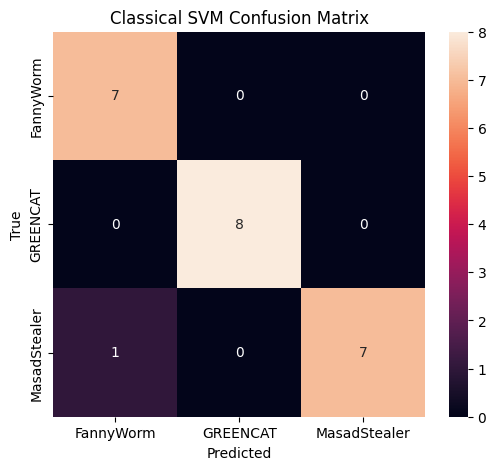

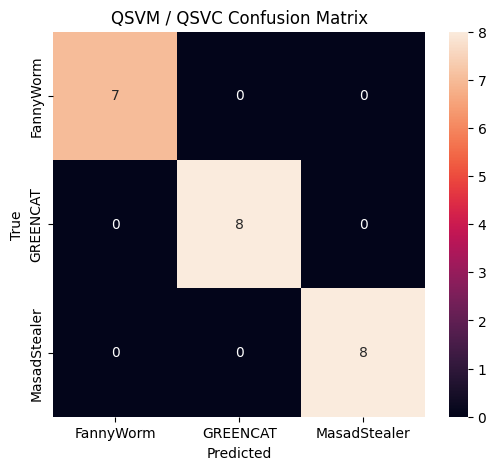

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

plot_cm(y_test, y_pred_classical, 'Classical SVM Confusion Matrix')
plot_cm(y_test, y_pred_qsvc, 'QSVM / QSVC Confusion Matrix')



## 9. Inspect the quantum kernel matrix

The kernel matrix shows how similar each malware sample is to other samples after quantum encoding.


Quantum kernel matrix shape: (52, 52)
[[1.    0.084 0.007 0.023 0.058]
 [0.084 1.    0.044 0.004 0.047]
 [0.007 0.044 1.    0.04  0.088]
 [0.023 0.004 0.04  1.    0.012]
 [0.058 0.047 0.088 0.012 1.   ]]


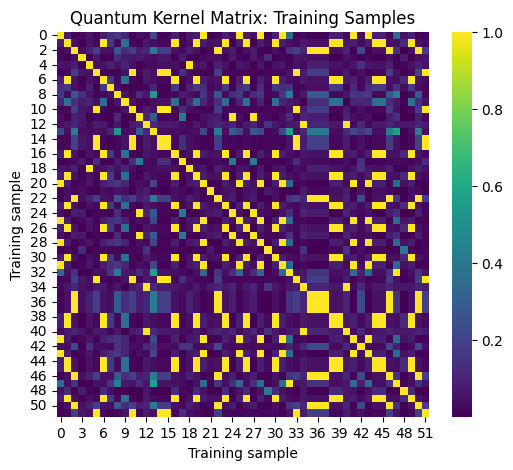

In [ ]:

K_train = quantum_kernel.evaluate(x_vec=X_train_q)
print('Quantum kernel matrix shape:', K_train.shape)
print(np.round(K_train[:5, :5], 3))

plt.figure(figsize=(6, 5))
sns.heatmap(K_train, cmap='viridis')
plt.title('Quantum Kernel Matrix: Training Samples')
plt.xlabel('Training sample')
plt.ylabel('Training sample')
plt.show()



## 10. Optional: Sifferent settings

Recommended experiments for students:

1. Increase `TOP_N_CLASSES` from 3 to 4 or 5.
2. Increase `SAMPLES_PER_CLASS` from 25 to 50.
3. Increase `N_QUBITS` from 4 to 6 or 8.
4. Compare `ZZFeatureMap` with `PauliFeatureMap`.
5. Compare QSVM against classical SVM, Random Forest, and Logistic Regression.

Note: QSVM runtime grows quickly because it computes many pairwise similarities.


In [ ]:

# Optional classical baselines
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Classical SVM RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train_q, y_train)
    pred = model.predict(X_test_q)
    print(f'{name}: {accuracy_score(y_test, pred):.4f}')

print(f'QSVM / QSVC: {accuracy_score(y_test, y_pred_qsvc):.4f}')


Logistic Regression: 0.9565
Random Forest: 1.0000
Classical SVM RBF: 0.9565
QSVM / QSVC: 1.0000



## 11. Optional IBM Quantum hardware note

For real IBM quantum hardware, we should **not** start with the full QSVM training because quantum kernel training requires many circuit executions.

A practical classroom approach is:

1. Train QSVM on a local simulator.
2. Select 2–5 malware samples.
3. Run only a small kernel demonstration on IBM hardware.
4. Compare noisy hardware kernel values with simulator kernel values.

This keeps cost and queue time manageable.


In [ ]:

# Optional template only. Run this only if you have IBM Quantum access configured.
# Real hardware execution APIs may change, so check the latest IBM Quantum documentation.

# !pip install -q qiskit-ibm-runtime
# from qiskit_ibm_runtime import QiskitRuntimeService
#
# QiskitRuntimeService.save_account(
#     channel='ibm_quantum',
#     token='PASTE_YOUR_IBM_QUANTUM_TOKEN_HERE',
#     overwrite=True
# )
# service = QiskitRuntimeService(channel='ibm_quantum')
# print(service.backends())


## Interpretation

For this QSVM malware family classification module:

- The **classical part** loads malware data, extracts/selects features, normalizes values, reduces dimensions, and evaluates results.
- The **quantum part** maps each malware feature vector into a quantum state using a feature map and computes quantum kernel similarities.
- The **SVM decision process** uses those kernel values for classification.

This Colab clearly demonstrate where classical computing starts and ends, where quantum encoding begins, and how the quantum kernel is used for cybersecurity classification.
